# Multilayer Perceptron - Regression
This project implements a complete supervised machine learning pipeline for a regression task, from raw data preprocessing through to model evaluation. The goal is to predict the median house price of a California district based on eight demographic and geographic features, using scikit-learn's California Housing dataset (20,640 samples).
The pipeline covers the full workflow: exploratory data analysis, stratified train/validation/test splitting, standardisation with leakage-free normalisation, a custom PyTorch Dataset/DataLoader setup, and a Multilayer Perceptron (MLP) trained with early stopping and best-model restoration. The project is implemented entirely in NumPy and PyTorch.

# Imports

In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)
np.random.seed(42)

# Data exploration

First few rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Shapes of input ndarray and label ndarray: (20640, 8) (20640,)
Input ndarray type: float64 
Label ndarray type: float64
Presence of missing values: False


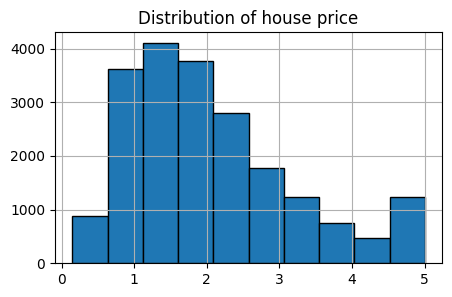

In [2]:
data_df = fetch_california_housing(as_frame=True)
print("First few rows of the dataset:")
print(data_df.frame.head())
data_df.target.hist(figsize=(5, 3), edgecolor="black")
plt.title("Distribution of house price")


data = fetch_california_housing()
X = data.data
y = data.target
print("Shapes of input ndarray and label ndarray:",X.shape, y.shape)
print("Input ndarray type:",X.dtype, "\nLabel ndarray type:",y.dtype)
print("Presence of missing values:", np.any(np.isnan(X)))

As we can see there are no non-numeric or missing values. However the ranges of different attributes differ in some cases so normalization is required to increase accuracy. In order to prevent data leakage I will normalize the data after splitting it into training, validation and test sets.

# Splitting the dataset

In [3]:
TRAINING_SET_RATIO = 0.6
VALIDATION_SET_RATIO = 0.2

n_training_samples = int(X.shape[0] * TRAINING_SET_RATIO)
n_val_samples = int(y.shape[0] * VALIDATION_SET_RATIO)
val_offset = n_training_samples
test_offset = n_training_samples + n_val_samples

indices = np.random.permutation(X.shape[0])
X, y = X[indices], y[indices]

X_train = X[:val_offset, :]
y_train = y[:val_offset]
X_val = X[val_offset:test_offset,:]
y_val = y[val_offset:test_offset]
X_test = X[test_offset:,:]
y_test = y[test_offset:]

print(f"Training inputs shape: {X_train.shape}, training labels shape: {y_train.shape}")
print(f"Validation inputs shape: {X_val.shape}, validation labels shape: {y_val.shape}")
print(f"Test inputs shape: {X_test.shape}, test labels shape: {y_test.shape}")

Training inputs shape: (12384, 8), training labels shape: (12384,)
Validation inputs shape: (4128, 8), validation labels shape: (4128,)
Test inputs shape: (4128, 8), test labels shape: (4128,)


# Normalization
I will transform the data into standard normal distribution. I will compute the mean and standard deviation only on the training set and apply those values to the validation and test set as well to prevent data leakage.

In [4]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0) + 1e-8

X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

print("Ranges of the attributes:")
for i in range (X_train.shape[1]):
    print(f"Attribute {i+1}: {np.amin(X_train[:,i]).round(3)} - {np.amax(X_train[:,i]).round(3)}")
    
print()
print(f"Means: {np.mean(X_train, axis=0).round(3)}")
print(f"Stds: {np.std(X_train, axis=0).round(3)}")

Ranges of the attributes:
Attribute 1: -1.782 - 5.883
Attribute 2: -2.191 - 1.843
Attribute 3: -1.962 - 54.559
Attribute 4: -1.632 - 70.772
Attribute 5: -1.262 - 24.352
Attribute 6: -0.78 - 92.885
Attribute 7: -1.441 - 2.976
Attribute 8: -2.4 - 2.536

Means: [-0. -0.  0. -0. -0. -0.  0. -0.]
Stds: [1. 1. 1. 1. 1. 1. 1. 1.]


# Model definition
The model will be a subclass of pytorch's nn.Module class. A single hidden layer of 32 neurons provides sufficient non-linear capacity for this dataset without overfitting risk.

In [5]:
class MLPReg(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32,1)
            #no activation function at the end in the case of regression
        )
    
    def forward(self,x):
        return self.layers(x)

model = MLPReg(input_dim = X_train.shape[1])

# Iterators
The model will receive the data in batches produced by iterators. I will use PyTorch's Dataset and DataLoader classes for my implementation.

In [6]:
class MLPRegDataset(Dataset):
    def __init__(self, X_split, y_split):
        self.xs = torch.tensor(X_split, dtype=torch.float32)
        self.ys = torch.tensor(y_split, dtype=torch.float32)

    def __len__(self):
        return self.xs.shape[0]

    def __getitem__(self, idx):
        return self.xs[idx, :], self.ys[idx, None]

train_dataset = MLPRegDataset(X_train,y_train)
val_dataset = MLPRegDataset(X_val,y_val)
test_dataset = MLPRegDataset(X_test,y_test)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#a few examples:
for X_batch, y_batch in val_loader:
    print(X_batch[:3,:])
    print(y_batch[:3,:])
    break

tensor([[-1.2255, -1.0836, -0.5980, -0.1701, -0.6146, -0.1547,  0.8918, -0.6480],
        [-0.4950,  1.8430, -0.4049,  0.0721, -0.1814, -0.0266, -0.7137,  0.6536],
        [ 1.1690,  0.4192,  0.2925, -0.1907, -0.1007,  0.0202,  0.7979, -1.2337]])
tensor([[0.9310],
        [1.8940],
        [3.4140]])


# Training with early stopping
Adam was chosen as the optimiser with a learning rate of 0.0003, lower than the default in order to produce smoother convergence. Batch size is set to 32, a standard choice that balances training speed and gradient stability. The early stopping patience of 30 epochs prevents overfitting while giving the model enough time to converge, and at the end of training the best-performing model is restored.

Best model updated in epoch 0
Best model updated in epoch 1
Best model updated in epoch 2
Best model updated in epoch 3
Best model updated in epoch 4
Best model updated in epoch 5
Best model updated in epoch 6
Best model updated in epoch 7
Best model updated in epoch 8
Best model updated in epoch 9
Best model updated in epoch 10
Best model updated in epoch 11
Best model updated in epoch 12
Best model updated in epoch 14
Best model updated in epoch 15
Best model updated in epoch 16
Best model updated in epoch 19
Best model updated in epoch 22
Best model updated in epoch 24
Best model updated in epoch 28
Best model updated in epoch 31
Best model updated in epoch 37
Best model updated in epoch 46
Best model updated in epoch 56
Best model updated in epoch 62
Best model updated in epoch 75
Best model updated in epoch 86
Best model updated in epoch 88
Best model updated in epoch 105
Best model updated in epoch 121
Best model updated in epoch 127
Best model updated in epoch 132
Best model upd

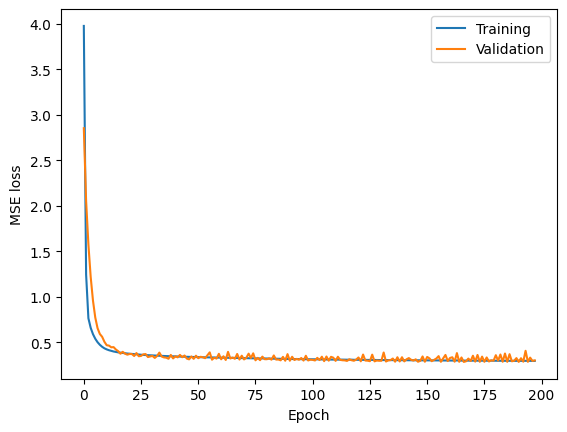

In [7]:
def model_training(model, loss_fn = nn.MSELoss()):
    max_epochs = 200
    learning_rate = 0.0003
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
    train_losses = []
    val_losses = []
    
    best_model = None
    best_val_loss = float('inf')
    early_stopping_patience = 30
    last_best_model_update_idx = 0
    
    for epoch_idx in range(max_epochs):
        
        # training phase
        model.train()
        epoch_train_losses=[]
    
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch) 
            loss = loss_fn(y_pred, y_batch)
            epoch_train_losses.append(loss.item())
            loss.backward() #back propagation
            optimizer.step() #adjust weights
    
        epoch_train_losses = torch.tensor(epoch_train_losses)
        avg_epoch_loss = epoch_train_losses.mean()
        train_losses.append(avg_epoch_loss.item())
    
        # validation phase
        model.eval()
        epoch_val_losses=[]
    
        for X_batch_val, y_batch_val in val_loader:
            with torch.no_grad():
                y_pred = model(X_batch_val) # during validation gradient computation is not required
            loss = loss_fn(y_pred, y_batch_val)
            epoch_val_losses.append(loss.item())
            #there is also no need for backward propagation or optimizer stepping
    
        epoch_val_losses = torch.tensor(epoch_val_losses)
        avg_epoch_val_loss = epoch_val_losses.mean()
        val_losses.append(avg_epoch_val_loss.item())
    
        # early stopping: best model update check
        if avg_epoch_val_loss < best_val_loss:
            best_val_loss = avg_epoch_val_loss
            best_model = copy.deepcopy(model)
            last_best_model_update_idx = epoch_idx
            print(f"Best model updated in epoch {epoch_idx}")
    
        # early stopping: breaking the training process
        if last_best_model_update_idx + early_stopping_patience < epoch_idx:
            print(f"Training is terminated by early stopping in epoch {epoch_idx}")
            break
    
    print("Training finished. Best model restored.")
    print(f"Training loss: {train_losses[last_best_model_update_idx]}, validation loss: {val_losses[last_best_model_update_idx]}")
    
    plt.plot(train_losses, label="Training")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

    return best_model

model = model_training(model)

The training and validation losses decrease together and converge closely, indicating the model is learning without significant overfitting.
The slightly lower validation loss is consistent with the model's limited capacity — it generalises well but may not capture all non-linearities in the data.
For context let's compare it to a simple linear regression.

# Simple model definition and training

In [8]:
class LinRegSimple(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 1)
        )
    
    def forward(self,x):
        return self.layers(x)

lin_model = LinRegSimple(input_dim = X_train.shape[1])

Best model updated in epoch 0
Best model updated in epoch 1
Best model updated in epoch 2
Best model updated in epoch 3
Best model updated in epoch 4
Best model updated in epoch 5
Best model updated in epoch 6
Best model updated in epoch 7
Best model updated in epoch 8
Best model updated in epoch 9
Best model updated in epoch 10
Best model updated in epoch 11
Best model updated in epoch 12
Best model updated in epoch 13
Best model updated in epoch 14
Best model updated in epoch 15
Best model updated in epoch 16
Best model updated in epoch 17
Best model updated in epoch 18
Best model updated in epoch 19
Best model updated in epoch 20
Best model updated in epoch 21
Best model updated in epoch 22
Best model updated in epoch 23
Best model updated in epoch 24
Best model updated in epoch 25
Best model updated in epoch 26
Best model updated in epoch 27
Best model updated in epoch 28
Best model updated in epoch 29
Best model updated in epoch 30
Best model updated in epoch 31
Best model updated

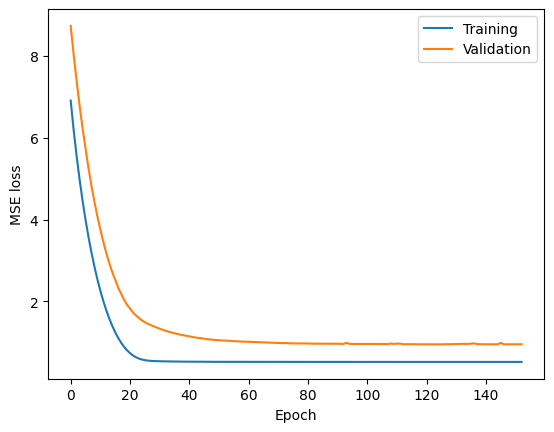

In [9]:
lin_model = model_training(lin_model)

The linear model produces higher losses in both the training and validation phases. The dataset is not describable with a strictly linear relation.

# Evaluation
The non-linear model performs better. For evaluation I will compute the average loss on the test set, show some prediction examples, and calculate mean absolute error and r2 scores. In the end I will visualise the predictions compared to the actual prices on a scatterplot.

For input [2.0280001163482666, 33.0, 5.458000183105469, 1.1009999513626099, 648.0, 2.8550000190734863, 37.130001068115234, -120.26000213623047]
the model predicted price 0.7798 while the true price is 0.588.
The absolute difference is 0.1918

For input [2.4730000495910645, 26.0, 4.35699987411499, 1.0820000171661377, 1415.0, 2.684999942779541, 33.86000061035156, -117.91000366210938]
the model predicted price 1.7135 while the true price is 1.658.
The absolute difference is 0.0555

For input [2.321000099182129, 48.0, 4.368000030517578, 1.059000015258789, 993.0, 2.4519999027252197, 34.040000915527344, -118.36000061035156]
the model predicted price 2.0188 while the true price is 1.394.
The absolute difference is 0.6248

For input [3.25, 32.0, 5.2210001945495605, 0.9399999976158142, 712.0, 2.8589999675750732, 34.689998626708984, -118.1500015258789]
the model predicted price 1.5382 while the true price is 1.075.
The absolute difference is 0.4632

For input [3.180999994277954, 24.0, 7.92600011

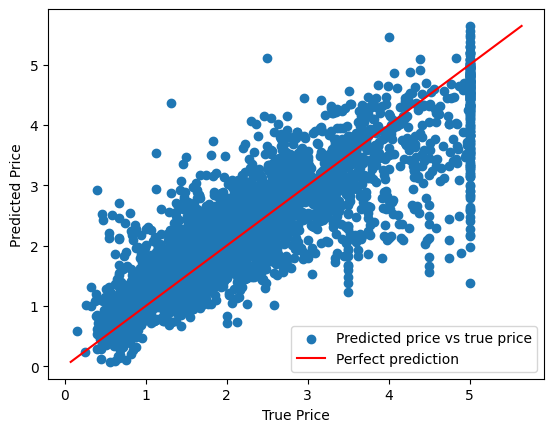

In [10]:
test_losses = []
y_preds = []
y_true = []
first_it = True
loss_fn = nn.MSELoss()
for X_batch_test, y_batch_test in test_loader:
    with torch.no_grad():
        y_pred = model(X_batch_test)
        test_losses.append(loss_fn(y_pred, y_batch_test).item())
        y_preds.append(y_pred)
        y_true.append(y_batch_test)
        if first_it:
            X_mean_t = torch.tensor(X_mean, dtype=torch.float32)
            X_std_t  = torch.tensor(X_std,  dtype=torch.float32)
            X_non_normalized = X_batch_test * X_std_t + X_mean_t #  denormalization
            for i in range (5):
                print(f"For input {X_non_normalized[i,:].round(decimals=3).tolist()}\nthe model predicted price {round(y_pred[i].item(),4)} while the true price is {round(y_batch_test[i].item(),4)}.")
                print(f"The absolute difference is {round(abs(y_pred[i].item() - y_batch_test[i].item()), 4)}\n")
            first_it = not first_it
print(f"Average test loss: {torch.tensor(test_losses).mean()}\n")

y_preds = torch.cat(y_preds).numpy()
y_true = torch.cat(y_true).numpy()

mae = mean_absolute_error(y_true,y_preds)
print(f"Mean absolute error: {mae}")
r2 = r2_score(y_true,y_preds)
print(f"R2 score: {r2}")

plt.scatter(y_true,y_preds,label="Predicted price vs true price")
min_val = min(y_true.min(), y_preds.min())
max_val = max(y_true.max(), y_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='Perfect prediction')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

The scatter plot of predicted vs true prices shows the model captures the general price trend well at mid-range values, with larger errors concentrated at the upper end of the price distribution.